# Prendido: ritmo de subida de la velocidad

Para cada medición `PRENDIDO_VS_ALTURA_*`:

1. En cada par se calcula, respecto del **centro seguido** (la partícula), el perfil `v_θ(r)`.
   Todas las mediciones se recortan al mismo intervalo de tiempo.
2. Del perfil salen tres velocidades en función del tiempo: la máxima, la media, y la de un
   radio fijo (el radio donde la velocidad es máxima al final de la medición).
3. Para cada una se elige el rango de subida (desde que la curva cruza el 10 % hasta que llega
   al 90 % de una velocidad máxima efectiva, el percentil 95) y se ajusta una recta en ese rango.
4. Se grafica la pendiente en función de la altura del agua, y al final se comparan las tres
   velocidades.

In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from estilo_poster import *   # colores y fuentes del póster (fondo oscuro)

fontsize = 30
usar_estilo(fontsize)

DATA = Path("../data glitter")
FIGURAS = Path("../figuras/FIGURAS FINALES")   # las del póster
# Nombres posibles (con vmax, vmedia o vradio, según VELOCIDAD):
#   sección 3-4: "ajuste_subida_vradio", "pendiente_vradio"
#   sección 5:   "comparacion_pendientes"
#   sección 6:   "rampa_subida_vradio", "pendiente_rampa_vradio"
GUARDAR = {"rampa_subida_vradio", "pendiente_rampa_vradio"}
analisis = sorted(DATA.glob("*PRENDIDO_VS_ALTURA_*/*/parametros.json"))


def guardar(fig, nombre, sufijo=""):
    # PNG a 300 dpi, solo si nombre está en GUARDAR. El sufijo se agrega al nombre del archivo.
    if nombre not in GUARDAR:
        return
    FIGURAS.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURAS / f"{nombre}{sufijo}.png", dpi=300)
    print(f"guardada: {FIGURAS / (nombre + sufijo)}.png")


def graficar_subida(ajustes, etiqueta, titulo):
    # v(t) de cada medición con la recta ajustada; el rango de subida va sombreado
    fig, axs = plt.subplots(len(ajustes), 1, figsize=(12, 6.5 if len(ajustes) == 1 else 4.3 * len(ajustes)),
                            sharex=True, constrained_layout=True, squeeze=False)
    for ax, a in zip(axs[:, 0], ajustes):
        ax.plot(a["t"], a["v"], ".", ms=4, color=AZUL, alpha=0.7)
        ax.axvspan(a["t1"], a["t2"], color=NARANJA, alpha=0.18, lw=0)
        ax.axhline(a["v_ef"], color=TEXTO_2, lw=1.5, ls="--")   # velocidad máxima efectiva
        tt = np.array([a["t1"], a["t2"]])
        ax.plot(tt, a["pendiente"] * tt + a["ordenada"], lw=3.5, color=NARANJA,
                label=f"pendiente {a['pendiente']:.3f} ± {a['err']:.3f} cm/s²")
        ax.set_ylabel(etiqueta)
        ax.set_ylim(bottom=0)
        if len(ajustes) == 1:   # un solo panel: la altura va de subtítulo, centrada bajo el título
            ax.set_title(f"altura del agua H = {a['H']:.1f} cm{a['detalle']}", fontsize=fontsize - 3,
                         fontweight="normal")
        else:
            ax.set_title(f"altura del agua H = {a['H']:.1f} cm{a['detalle']}", fontsize=fontsize - 2, loc="left")
        ax.legend(loc="lower right")
    axs[-1, 0].set_xlabel("t [s]")
    titulo_centrado(fig, axs[-1, 0], titulo)
    return fig


def graficar_pendientes(H, pend, err, etiqueta, titulo):
    fig, ax = plt.subplots(figsize=(11, 8), constrained_layout=True)
    ax.errorbar(H, pend, yerr=err, fmt="o", ms=13, capsize=8, capthick=2.5, elinewidth=2.5, color=AZUL)
    ax.set_xlabel("altura del agua H [cm]")
    ax.set_ylabel(etiqueta)
    ax.set_ylim(bottom=0)
    ax.set_title(titulo)
    return fig

## 1. Cargar: perfil de velocidad de cada par

Todo se mide alrededor del centro seguido de cada par. De cada medición se guarda:

- `v_max`: los vectores se agrupan en anillos de `ANCHO_ANILLO`, se promedia `v_θ` en cada
  anillo y se toma el anillo con mayor `v_θ`.
- `v_media`: el promedio de `v_θ` de todos los vectores entre `R_MIN` y `R_MEDIA`. `R_MEDIA` es
  **el mismo para todas las mediciones** y tiene que ser lo bastante chico para que, aunque el
  centro se mueva, ese círculo quede siempre entero dentro de la región analizada (la celda lo
  verifica).
- el perfil por anillos de cada par, para la velocidad a radio fijo.
- el **error** de cada una: el error estándar del promedio (desvío de los `v_θ` de los
  vectores promediados, dividido por la raíz de cuántos son). Dice qué tan bien definido
  está el promedio de ese par; no incluye las fluctuaciones del flujo de un par a otro.

Los vectores más cerca del centro que `R_MIN` son pocos y se dejan afuera.

**Mismo intervalo de tiempo.** Con `RECORTAR = True` todas las mediciones se cortan en la
duración de la más corta (`T_MAX = None`) o en `T_MAX` segundos. Así ninguna tiene más tiempo
que las otras para seguir subiendo.

Esta celda es la lenta (lee los CSV).

In [ ]:
ANCHO_ANILLO = 0.25   # cm
R_MIN = 1.0           # cm
R_MEDIA = 6.0         # cm, el mismo en todas las mediciones
MIN_VECTORES = 5      # vectores por anillo y por par
RECORTAR = True       # cortar todas las mediciones al mismo intervalo de tiempo
T_MAX = None          # s; None = la duración de la medición más corta


def velocidades_en_el_tiempo(p):
    P = json.loads(p.read_text(encoding="utf-8"))
    cam = P["camaras"]["A"]
    cal = cam["calibracion"]
    df = pd.read_csv(p.parent / cam["csv"], usecols=["frame", "x_mm", "y_mm", "u_mm_s", "v_mm_s", "valido"])
    df = df[df["valido"] == 1]
    centro = pd.read_csv(p.parent / cam["csv_centro"]).set_index("frame")

    # El círculo de radio R_MEDIA alrededor del centro seguido tiene que caer dentro de la región analizada
    s = cal["mm_por_px"] / 10                                         # cm/px
    cx, cy = np.array(cal["centro_vortice_px"]) * s
    alejamiento = np.hypot(centro["xc_mm"] / 10 - cx, centro["yc_mm"] / 10 - cy).max()
    libre = cal["radio_roi_px"] * s - alejamiento
    if R_MEDIA > libre:
        print(f"¡OJO! {P['grabacion_info']['nombre']}: el círculo de {R_MEDIA} cm se sale de la región "
              f"analizada en algunos pares (el máximo que entra siempre es {libre:.2f} cm)")

    c = centro.loc[df["frame"]]
    dx = (df["x_mm"].to_numpy() - c["xc_mm"].to_numpy()) / 10       # cm
    dy = (df["y_mm"].to_numpy() - c["yc_mm"].to_numpy()) / 10
    r = np.hypot(dx, dy)
    ok = r >= R_MIN
    vectores = pd.DataFrame({
        "frame": df["frame"].to_numpy()[ok],
        "r": r[ok],
        "vt": (df["v_mm_s"].to_numpy()[ok] * dx[ok] - df["u_mm_s"].to_numpy()[ok] * dy[ok]) / r[ok] / 10,   # cm/s
    })

    perfil = vectores.groupby(["frame", np.floor(vectores["r"] / ANCHO_ANILLO)])["vt"].agg(["mean", "std", "size"])
    perfil = perfil[perfil["size"] >= MIN_VECTORES]
    vmax = perfil["mean"].groupby(level="frame").max()
    adentro = vectores[vectores["r"] <= R_MEDIA]
    vmedia = adentro.groupby("frame")["vt"].mean()
    v = pd.DataFrame({"vmax": vmax, "vmedia": vmedia}).dropna()
    anillos = perfil["mean"].unstack().reindex(v.index)               # filas = pares, columnas = anillos
    # error estándar de cada promedio: desvío de los vectores / raíz de cuántos son
    errores = (perfil["std"] / np.sqrt(perfil["size"])).unstack().reindex(index=v.index, columns=anillos.columns)
    perfil_v, perfil_err = anillos.to_numpy(), errores.to_numpy()
    del_maximo = np.nanargmax(perfil_v, axis=1)                       # el anillo del máximo en cada par
    vmedia_err = adentro.groupby("frame")["vt"].sem().reindex(v.index)

    return dict(nombre=P["grabacion_info"]["nombre"],
                H=P["recipiente"]["altura_agua_mm"] / 10,             # cm
                V=P["recipiente"]["volumen_agua_ml"],
                t=centro.loc[v.index, "t_s"].to_numpy(),
                vmax=v["vmax"].to_numpy(),
                vmax_err=perfil_err[np.arange(len(del_maximo)), del_maximo],
                vmedia=v["vmedia"].to_numpy(),
                vmedia_err=vmedia_err.to_numpy(),
                radios=(anillos.columns.to_numpy() + 0.5) * ANCHO_ANILLO,   # cm, centro de cada anillo
                perfil=perfil_v,                                      # NaN: anillo con pocos vectores en ese par
                perfil_err=perfil_err)


mediciones = sorted((velocidades_en_el_tiempo(p) for p in analisis), key=lambda m: m["H"])
H = np.array([m["H"] for m in mediciones])

t_corte = min(m["t"][-1] for m in mediciones) if T_MAX is None else T_MAX
for m in mediciones:
    duracion = m["t"][-1]
    if RECORTAR:
        entra = m["t"] <= t_corte
        for clave in ("t", "vmax", "vmax_err", "vmedia", "vmedia_err", "perfil", "perfil_err"):
            m[clave] = m[clave][entra]
    print(f"{m['nombre']}:  H = {m['H']:.1f} cm,  V = {m['V']:.0f} ml,  {len(m['t'])} pares,  "
          f"{m['t'][-1]:.1f} s" + (f"  (recortada, duraba {duracion:.1f} s)" if duracion - m["t"][-1] > 1 else ""))

## 2. Las tres velocidades

- `"maxima"`: `v_max(t)`, el máximo del perfil de cada par. El radio donde está el máximo
  cambia de un par a otro.
- `"media"`: `v_media(t)`, el promedio entre `R_MIN` y `R_MEDIA`.
- `"radio_fijo"`: `v_θ(t)` en un solo anillo, siempre el mismo. El anillo es el que tiene la
  velocidad más alta en el perfil promediado en los últimos `T_RADIO_FIJO` segundos de esa
  medición (el radio del máximo del vórtice ya formado). El radio sale distinto en cada
  medición; la celda lo muestra y va en el título de cada panel.

`VELOCIDAD` elige cuál se muestra en detalle en las secciones 3 y 4 (para cambiarla, volver a
correr desde esta celda; no hace falta volver a cargar). La sección 5 compara las tres.

`MOSTRAR`: qué mediciones se grafican (índices en la lista ordenada por altura). Los cálculos
se hacen siempre en todas.

In [ ]:
VELOCIDAD = "radio_fijo"      # "maxima", "media" o "radio_fijo"
T_RADIO_FIJO = 5.0            # s, para "radio_fijo": tramo final donde se busca el radio del máximo
MOSTRAR = [2]                 # qué mediciones se grafican, en la lista ordenada por H

OPCIONES = {   # sufijo de las figuras, símbolo, nombre corto, título de la subida, título de las pendientes
    "maxima": ("vmax", "v_{max}", "velocidad máxima",
               "Subida de la velocidad máxima al prender el agitador",
               "Ritmo de subida según cantidad de agua"),
    "media": ("vmedia", "v_{media}", f"velocidad media ({R_MIN:g} a {R_MEDIA:g} cm)",
              f"Subida de la velocidad media ({R_MIN:g} cm < r < {R_MEDIA:g} cm)",
              "Ritmo de subida de la velocidad media"),
    "radio_fijo": ("vradio", r"v_\theta(r_{fijo})", "velocidad a radio fijo",
                   "Subida de la velocidad en el radio del máximo final",
                   "Ritmo de subida de la velocidad a radio fijo"),
}


def serie_con_error(m, opcion):
    # t, v(t), el error de cada punto y el texto que va en el título del panel, para una de las tres opciones
    detalle = ""
    if opcion == "maxima":
        v, err = m["vmax"], m["vmax_err"]
    elif opcion == "media":
        v, err = m["vmedia"], m["vmedia_err"]
    else:
        final = m["perfil"][m["t"] >= m["t"][-1] - T_RADIO_FIJO]
        medidos = np.isfinite(final).sum(axis=0)
        perfil_final = np.where(medidos >= max(len(final) / 2, 1),          # anillos medidos en la mitad de los pares
                                np.nansum(final, axis=0) / np.maximum(medidos, 1), np.nan)
        k = int(np.nanargmax(perfil_final))
        v, err = m["perfil"][:, k], m["perfil_err"][:, k]
        detalle = f",  r = {m['radios'][k]:.2f} cm"
    medido = np.isfinite(v)   # a radio fijo, los pares donde ese anillo tiene pocos vectores quedan afuera
    return m["t"][medido], v[medido], err[medido], detalle


def serie(m, opcion):
    t, v, _, detalle = serie_con_error(m, opcion)
    return t, v, detalle


SUFIJO, SIMBOLO, _, TITULO_SUBIDA, TITULO_PENDIENTE = OPCIONES[VELOCIDAD]
print(f"se muestra en detalle la velocidad {VELOCIDAD}")
if VELOCIDAD == "radio_fijo":
    for m in mediciones:
        print(f"  H = {m['H']:.1f} cm:  radio fijo{serie(m, 'radio_fijo')[2]}")

## 3. Ajuste lineal en el rango de subida

**Rango de subida.** Para cada curva:

1. **Velocidad máxima efectiva** `v_ef`: el percentil `PERCENTIL` de todas las velocidades
   medidas (el máximo crudo sería un punto ruidoso). Es la línea punteada.
2. **Subida**: desde que la curva cruza el `CRUCE_BAJO` de `v_ef` hasta que llega al
   `CRUCE_ALTO`. Está sombreada.

**Ajuste.** Una recta ajustada a todos los puntos medidos (crudos) dentro de ese rango.

**Incerteza de la pendiente.** Suma en cuadratura de dos partes:

- **Estadística.** El error del ajuste por cuadrados mínimos supone que cada punto es
  independiente de los demás, y acá no lo son: dos pares seguidos comparten un cuadro y las
  fluctuaciones del flujo duran muchos pares, así que los residuos vecinos se parecen. Se mide
  esa correlación (la autocorrelación de los residuos, sumada hasta su primer cruce por cero) y
  el error del ajuste se multiplica por `√(N / N_ef)`, donde `N_ef` es el número de puntos
  realmente independientes. La tabla de la sección 4 muestra `N` y `N_ef`.
- **Del rango.** La subida no es una recta perfecta, así que la pendiente depende de dónde
  empieza y termina el rango. Se repite el ajuste moviendo cada cruce `± VARIACION_RANGO` (con
  los valores por defecto: empezar en el 5, 10 o 15 % y terminar en el 85, 90 o 95 %, las 9
  combinaciones) y se toma el desvío cuadrático medio de esas pendientes respecto de la
  nominal. Con `VARIACION_RANGO = 0` esta parte no se cuenta.

No está incluido lo que cambiaría la pendiente al repetir la medición (hay una sola por
altura) ni el error de la calibración mm/px, que es un factor común a toda la curva.

Opciones:

- `DESDE_LA_BASE`: en algunas mediciones el agua ya giraba un poco antes de prender
  (`v_base`, la mediana de los primeros 3 s) y esa velocidad ya está por encima del 10 % de
  `v_ef`: el cruce "ocurre" en `t = 0`. Con `True`, los porcentajes se miden sobre la base: los
  niveles son `v_base + fracción·(v_ef − v_base)`. Con `False` son `fracción·v_ef`, tal cual.
- `SUAVIZADO_CRUCES_S`: los cruces se buscan en la curva suavizada con esta media móvil, para
  que no los dispare un punto ruidoso suelto. Con `0` se usa la curva cruda.
- `VENTANA_MANUAL`: para fijar a mano el rango de alguna medición (en segundos). En ese caso
  la incerteza es solo la estadística.

El punto bajo es el último cruce hacia arriba antes de llegar al nivel alto (si la curva
toca el nivel bajo varias veces antes de arrancar, vale la última).

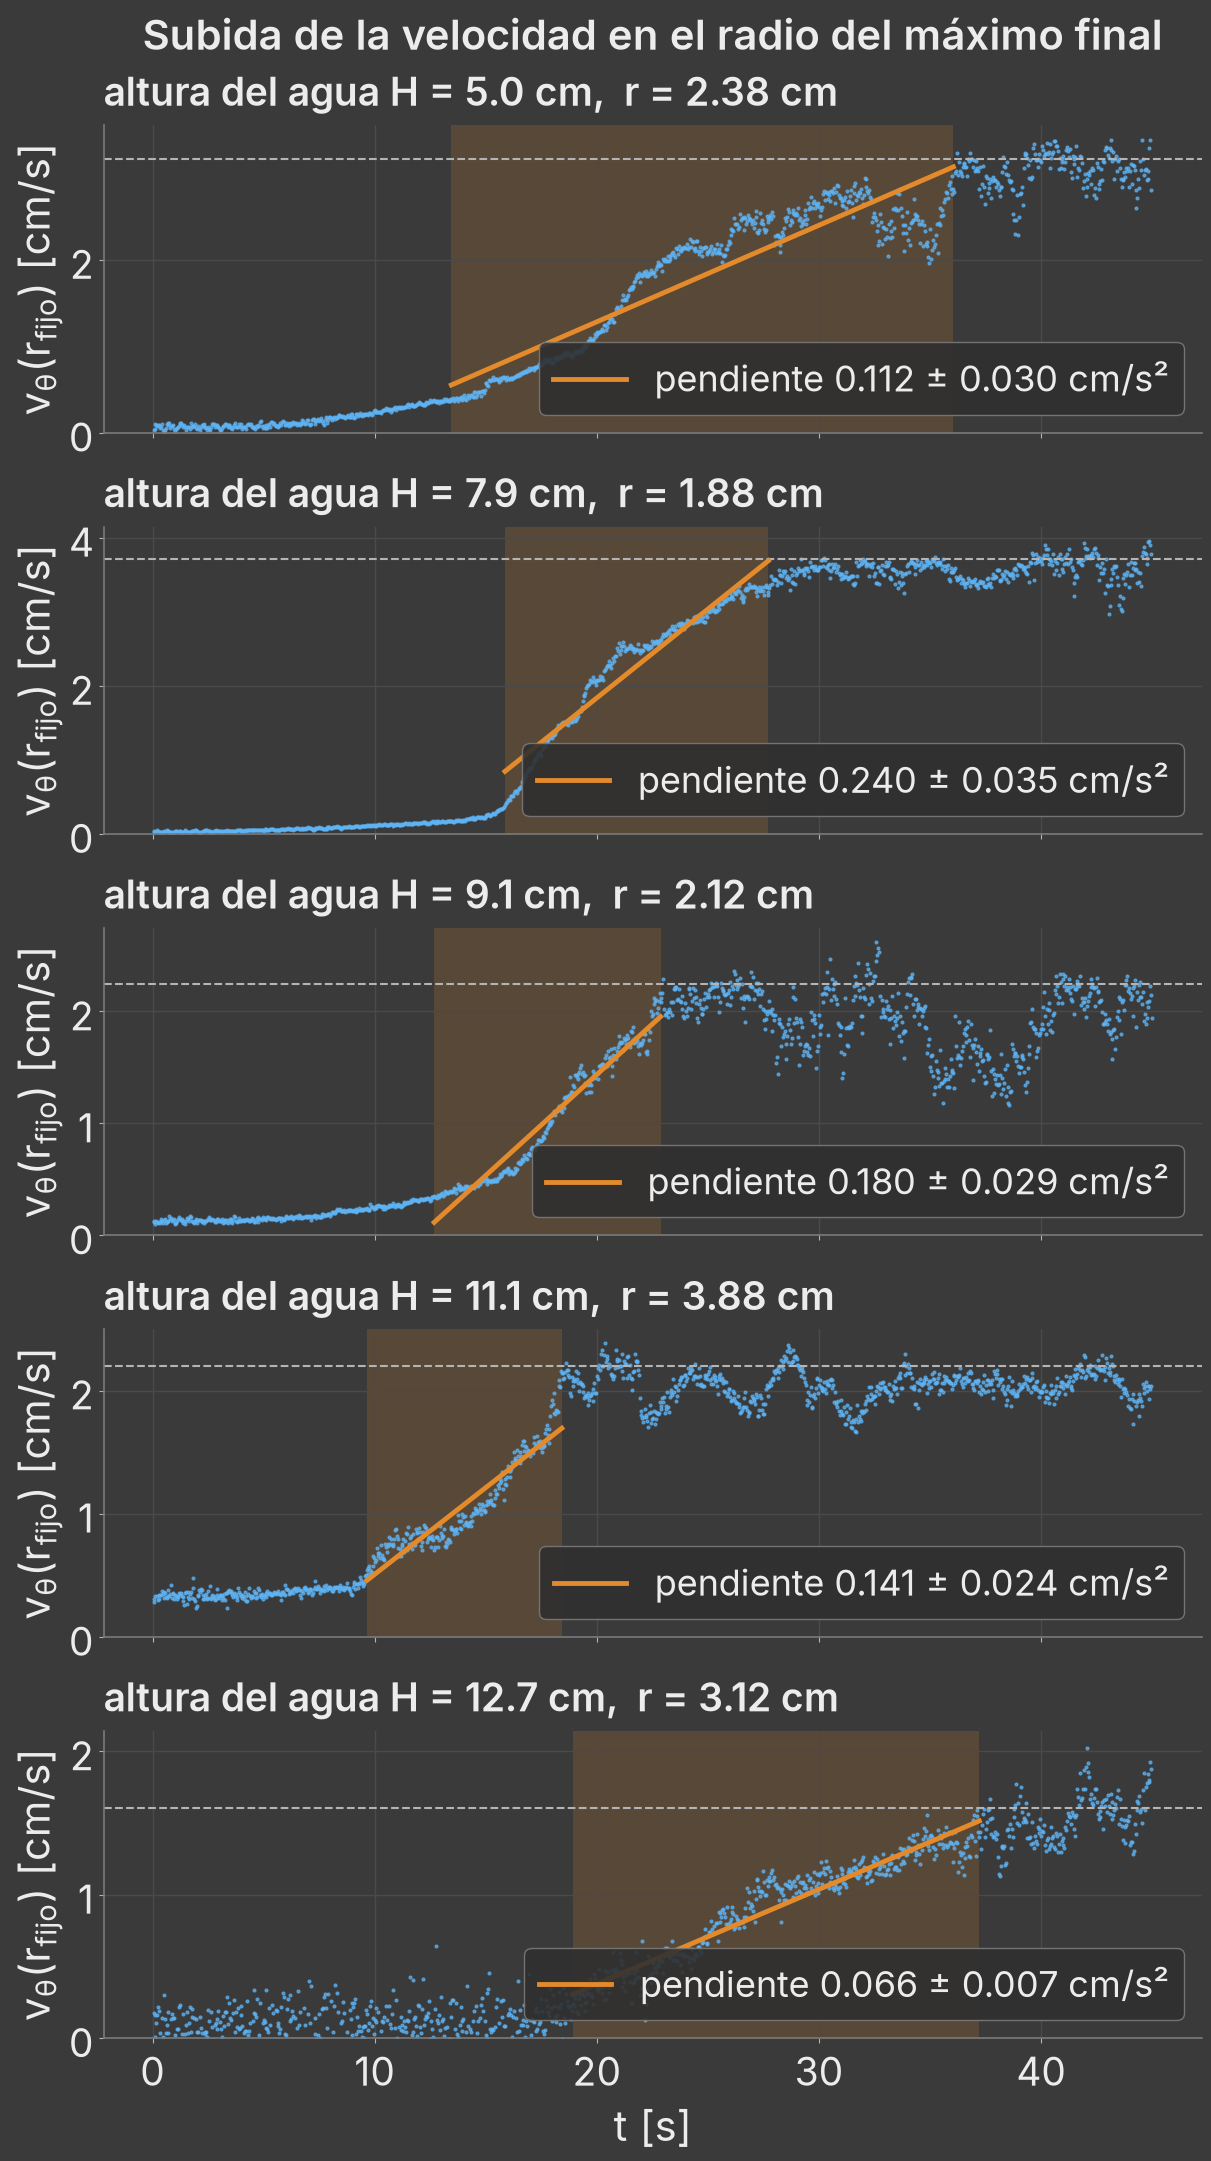

In [4]:
PERCENTIL = 95
CRUCE_BAJO, CRUCE_ALTO = 0.10, 0.90
VARIACION_RANGO = 0.05     # para la incerteza: cada cruce se mueve ± esto; 0 = solo la parte estadística
DESDE_LA_BASE = True
SUAVIZADO_CRUCES_S = 1.0   # s; 0 = curva cruda
VENTANA_MANUAL = {}        # p.ej. {"PRENDIDO_VS_ALTURA_3": (11, 18)}


def rango_de_subida(t, v, fraccion_baja, fraccion_alta):
    n = max(1, round(SUAVIZADO_CRUCES_S / np.median(np.diff(t))))
    curva = pd.Series(v).rolling(n, center=True, min_periods=1).mean().to_numpy()
    v_ef = np.percentile(v, PERCENTIL)
    v_base = np.median(v[t < t[0] + 3]) if DESDE_LA_BASE else 0.0
    bajo = v_base + fraccion_baja * (v_ef - v_base)
    alto = v_base + fraccion_alta * (v_ef - v_base)

    i2 = np.argmax(curva >= alto) if (curva >= alto).any() else np.argmax(curva)
    abajo = np.flatnonzero(curva[:i2] < bajo)
    i1 = abajo[-1] + 1 if len(abajo) else 0
    return t[i1], t[i2], v_ef, v_base


def recta(t, v, t1, t2):
    # Pendiente, ordenada, error de la pendiente (corregido por la correlación entre puntos vecinos),
    # número de puntos y número de puntos independientes
    sel = (t >= t1) & (t <= t2)
    (a, b), cov = np.polyfit(t[sel], v[sel], 1, cov=True)
    res = v[sel] - (a * t[sel] + b)
    n = len(res)
    rho = np.correlate(res, res, "full")[n - 1:] / (res @ res)       # autocorrelación de los residuos
    no_positivos = np.flatnonzero(rho[1:] <= 0)
    corte = no_positivos[0] + 1 if len(no_positivos) else n           # hasta el primer cruce por cero
    k = np.arange(1, corte)
    inflacion = 1 + 2 * np.sum((1 - k / n) * rho[1:corte])            # N / N_ef
    return a, b, np.sqrt(cov[0, 0] * inflacion), n, n / inflacion


def ajustar_subida(m, opcion):
    t, v, detalle = serie(m, opcion)
    t1, t2, v_ef, v_base = rango_de_subida(t, v, CRUCE_BAJO, CRUCE_ALTO)
    if m["nombre"] in VENTANA_MANUAL:
        t1, t2 = VENTANA_MANUAL[m["nombre"]]
    elif t1 == t[0]:
        print(f"¡OJO! {m['nombre']} ({opcion}): la curva arranca por encima del nivel bajo; "
              f"el rango empieza al principio de la grabación")
    pendiente, ordenada, err_est, n, n_ef = recta(t, v, t1, t2)

    # Incerteza del rango: el mismo ajuste con cada cruce corrido ± VARIACION_RANGO
    err_rango = 0.0
    if VARIACION_RANGO > 0 and m["nombre"] not in VENTANA_MANUAL:
        corrimientos = (-VARIACION_RANGO, 0.0, VARIACION_RANGO)
        desvios = []
        for d_bajo in corrimientos:
            for d_alto in corrimientos:
                if d_bajo == d_alto == 0:
                    continue
                t1v, t2v, _, _ = rango_de_subida(t, v, max(CRUCE_BAJO + d_bajo, 0.01), min(CRUCE_ALTO + d_alto, 0.99))
                desvios.append(recta(t, v, t1v, t2v)[0] - pendiente)
        err_rango = np.sqrt(np.mean(np.square(desvios)))

    return dict(nombre=m["nombre"], H=m["H"], V=m["V"], t=t, v=v, detalle=detalle,
                t1=t1, t2=t2, v_ef=v_ef, v_base=v_base, pendiente=pendiente, ordenada=ordenada,
                n=n, n_ef=n_ef, err_est=err_est, err_rango=err_rango, err=np.hypot(err_est, err_rango))


ajustes = [ajustar_subida(m, VELOCIDAD) for m in mediciones]

fig = graficar_subida([ajustes[i] for i in MOSTRAR], rf"${SIMBOLO}$ [cm/s]", TITULO_SUBIDA)
guardar(fig, f"ajuste_subida_{SUFIJO}")
plt.show()

## 4. Pendiente en función de la altura del agua

Para la velocidad elegida en `VELOCIDAD`.

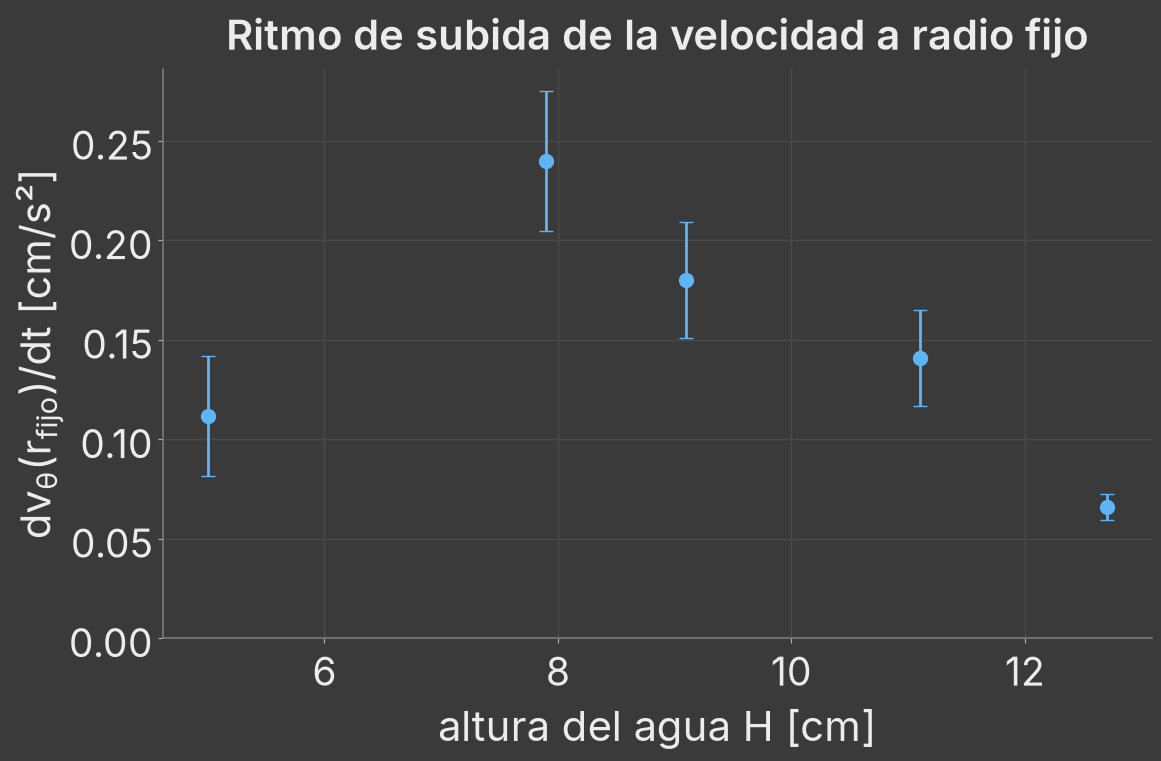

,H [cm],V [ml],v_base [cm/s],v_ef (p95) [cm/s],subida [s],pendiente [cm/s²],incerteza [cm/s²],estadística,del rango,N,N_ef
PRENDIDO_VS_ALTURA_1,5.0,1200.0,0.07,3.17,13.4 a 36.0,0.1118,0.0302,0.0191,0.0234,544,6.3
PRENDIDO_VS_ALTURA_2,7.9,1800.0,0.04,3.71,15.9 a 27.7,0.2398,0.0354,0.0269,0.0230,286,5.4
PRENDIDO_VS_ALTURA_3,9.1,2400.0,0.13,2.24,12.7 a 22.9,0.1802,0.0292,0.0138,0.0257,260,8.0
PRENDIDO_VS_ALTURA_4,11.1,3000.0,0.33,2.20,9.6 a 18.4,0.1408,0.0242,0.0212,0.0116,236,6.3
PRENDIDO_VS_ALTURA_5,12.7,3600.0,0.07,1.61,18.9 a 37.2,0.0661,0.0067,0.0055,0.0037,441,12.1


In [5]:
pend = np.array([a["pendiente"] for a in ajustes])
err = np.array([a["err"] for a in ajustes])

fig = graficar_pendientes(H, pend, err, rf"$d{SIMBOLO}/dt$ [cm/s²]", TITULO_PENDIENTE)
guardar(fig, f"pendiente_{SUFIJO}")
plt.show()

pd.DataFrame({
    "H [cm]": H,
    "V [ml]": [a["V"] for a in ajustes],
    "v_base [cm/s]": [round(a["v_base"], 2) for a in ajustes],
    f"v_ef (p{PERCENTIL:g}) [cm/s]": [round(a["v_ef"], 2) for a in ajustes],
    "subida [s]": [f"{a['t1']:.1f} a {a['t2']:.1f}" for a in ajustes],
    "pendiente [cm/s²]": pend.round(4),
    "incerteza [cm/s²]": err.round(4),
    "  estadística": [round(a["err_est"], 4) for a in ajustes],
    "  del rango": [round(a["err_rango"], 4) for a in ajustes],
    "N": [a["n"] for a in ajustes],
    "N_ef": [round(a["n_ef"], 1) for a in ajustes],
}, index=[a["nombre"] for a in ajustes])

## 5. Comparación de las tres velocidades

El mismo ajuste, hecho con la velocidad máxima, la media y la de radio fijo. Las barras son la
incerteza de cada pendiente (sección 3).

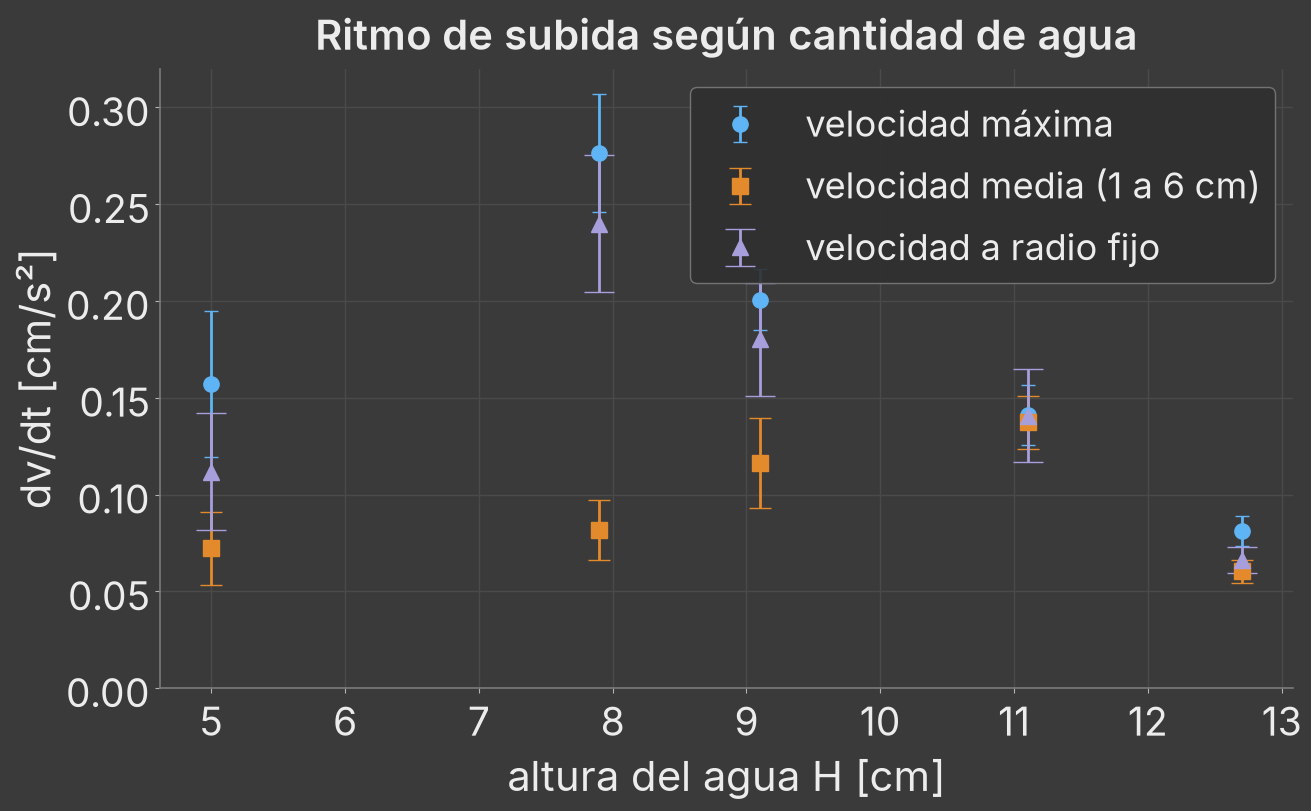

,H [cm],maxima [cm/s²],media [cm/s²],radio_fijo [cm/s²]
PRENDIDO_VS_ALTURA_1,5.0,0.157 ± 0.038,0.072 ± 0.019,0.112 ± 0.030
PRENDIDO_VS_ALTURA_2,7.9,0.277 ± 0.031,0.082 ± 0.016,0.240 ± 0.035
PRENDIDO_VS_ALTURA_3,9.1,0.201 ± 0.016,0.117 ± 0.023,0.180 ± 0.029
PRENDIDO_VS_ALTURA_4,11.1,0.141 ± 0.016,0.137 ± 0.014,0.141 ± 0.024
PRENDIDO_VS_ALTURA_5,12.7,0.081 ± 0.008,0.060 ± 0.006,0.066 ± 0.007


In [6]:
COLOR_OPCION = {"maxima": AZUL, "media": NARANJA, "radio_fijo": VIOLETA}
MARCADOR_OPCION = {"maxima": "o", "media": "s", "radio_fijo": "^"}

comparacion = {opcion: [ajustar_subida(m, opcion) for m in mediciones] for opcion in OPCIONES}

fig, ax = plt.subplots(figsize=(13, 8), constrained_layout=True)
for k, (opcion, lista) in enumerate(comparacion.items()):
    # los tres van en la misma H: tapas de distinto ancho para distinguir las barras que se superponen
    ax.errorbar(H, [a["pendiente"] for a in lista], yerr=[a["err"] for a in lista],
                fmt=MARCADOR_OPCION[opcion], ms=11, capsize=5 + 3 * k, lw=2, color=COLOR_OPCION[opcion],
                label=OPCIONES[opcion][2])
ax.set_xlabel("altura del agua H [cm]")
ax.set_ylabel(r"$dv/dt$ [cm/s²]")
ax.set_ylim(bottom=0)
ax.set_title("Ritmo de subida según cantidad de agua")
ax.legend()
guardar(fig, "comparacion_pendientes")
plt.show()

tabla = pd.DataFrame({"H [cm]": H}, index=[m["nombre"] for m in mediciones])
for opcion, lista in comparacion.items():
    tabla[f"{opcion} [cm/s²]"] = [f"{a['pendiente']:.3f} ± {a['err']:.3f}" for a in lista]
tabla

## 6. Ajuste constante – lineal – constante

Otra forma de medir la subida, sin elegir un rango con umbrales. A toda la curva `v(t)` de cada
medición (la velocidad elegida en `VELOCIDAD`; para el póster, la de radio fijo) se le ajusta
una función de tres tramos:

- constante en `v_ini` hasta que arranca la subida, en `t_arranque`;
- una rampa de pendiente constante que dura `duración`;
- constante en `v_fin = v_ini + pendiente · duración` hasta el final.

Los cuatro parámetros (`v_ini`, `pendiente`, `t_arranque`, `duración`) salen del ajuste por
cuadrados mínimos usando todos los puntos: dónde empieza y dónde termina la subida lo decide el
ajuste. La rampa está sombreada.

**Error de cada punto.** La banda alrededor de los puntos es el error estándar del promedio de
ese par (sección 1). El ajuste **no** pesa los puntos con ese error: es mucho más chico que lo
que la velocidad fluctúa de verdad de un par a otro (remolinos que pasan por el anillo), así que
usarlo de peso le daría una precisión que el flujo no tiene. La tabla compara los dos.

**Incerteza de los parámetros.** Sale de la dispersión de los residuos del ajuste, corregida
porque los puntos vecinos no son independientes (igual que en la sección 3): se multiplica por
`√(N / N_ef)`, con `N_ef` el número de puntos independientes según la autocorrelación de los
residuos de toda la curva. No incluye lo que cambiaría la pendiente al repetir la medición (hay
una sola por altura) ni el error de la calibración mm/px.

Respeta `VELOCIDAD`, el recorte de la sección 1 y `MOSTRAR`. El radio de cada medición lo imprime
la sección 2.


In [ ]:
from scipy.optimize import curve_fit


def constante_lineal_constante(t, v_ini, pendiente, t_arranque, duracion):
    return v_ini + pendiente * np.clip(t - t_arranque, 0, duracion)


def media_movil(v, n):
    # centrada; en los bordes promedia los puntos que haya
    return np.convolve(v, np.ones(n), "same") / np.convolve(np.ones(len(v)), np.ones(n), "same")


def ajustar_rampa(m, opcion):
    t, v, v_err, detalle = serie_con_error(m, opcion)

    # Valores iniciales: velocidad de los primeros 3 s, percentil 95, y cruces del 10 % y el 90 %
    suave = media_movil(v, max(1, round(1.0 / np.median(np.diff(t)))))
    v_ini, v_fin = np.median(v[t < t[0] + 3]), np.percentile(v, 95)
    t1 = t[np.argmax(suave > v_ini + 0.1 * (v_fin - v_ini))]
    t2 = t[np.argmax(suave > v_ini + 0.9 * (v_fin - v_ini))]
    duracion = max(t2 - t1, 1.0)

    pars, cov = curve_fit(constante_lineal_constante, t, v, p0=[v_ini, (v_fin - v_ini) / duracion, t1, duracion],
                          bounds=([-np.inf, 0, t[0], 0.5], [np.inf, np.inf, t[-1], t[-1] - t[0]]))
    v_ini, pendiente, t_arranque, duracion = pars

    # Puntos independientes: autocorrelación de los residuos, sumada hasta su primer cruce por cero
    res = v - constante_lineal_constante(t, *pars)
    N = len(res)
    rho = np.correlate(res, res, "full")[N - 1:] / (res @ res)
    no_positivos = np.flatnonzero(rho[1:] <= 0)
    corte = no_positivos[0] + 1 if len(no_positivos) else N
    k = np.arange(1, corte)
    inflacion = 1 + 2 * np.sum((1 - k / N) * rho[1:corte])            # N / N_ef
    err_ini, err_pendiente, err_arranque, err_duracion = np.sqrt(np.diag(cov) * inflacion)

    return dict(nombre=m["nombre"], H=m["H"], V=m["V"], t=t, v=v, v_err=v_err, detalle=detalle, pars=pars,
                v_ini=v_ini, v_fin=v_ini + pendiente * duracion, t_arranque=t_arranque, duracion=duracion,
                pendiente=pendiente, err=err_pendiente, err_arranque=err_arranque, err_duracion=err_duracion,
                n=N, n_ef=N / inflacion, rms=np.sqrt(np.mean(res**2)))


def graficar_rampa(lista, etiqueta, titulo):
    # v(t) con el error de cada punto y el ajuste constante – lineal – constante; la rampa va sombreada
    varias = len(lista) > 1
    fig, axs = plt.subplots(len(lista), 1, figsize=(13, 3.9 * len(lista) + 1.2 if varias else 6.5),
                            sharex=True, constrained_layout=True, squeeze=False)
    for i, (ax, a) in enumerate(zip(axs[:, 0], lista)):
        banda = ax.fill_between(a["t"], a["v"] - a["v_err"], a["v"] + a["v_err"], color=AZUL, alpha=0.35, lw=0)
        puntos, = ax.plot(a["t"], a["v"], ".", ms=5, color=AZUL)
        ax.axvspan(a["t_arranque"], a["t_arranque"] + a["duracion"], color=NARANJA, alpha=0.16, lw=0)
        tt = np.array([a["t"][0], a["t_arranque"], a["t_arranque"] + a["duracion"], a["t"][-1]])
        ajuste, = ax.plot(tt, constante_lineal_constante(tt, *a["pars"]), lw=4, color=NARANJA,
                          solid_joinstyle="round")
        # lugar arriba de los datos para la leyenda (una fila, o dos donde se explica la banda)
        filas = 1 if varias and i > 0 else 2
        ax.set_ylim(min(0, np.percentile(a["v"] - a["v_err"], 1)), np.max(a["v"] + a["v_err"]) * (1.08 + 0.2 * filas))
        ax.margins(x=0.02)
        pendiente = f"pendiente {a['pendiente']:.3f} ± {a['err']:.3f} cm/s²"
        if varias:
            ax.set_title(f"H = {a['H']:.1f} cm", fontsize=fontsize - 3, loc="left", pad=8)
            # la banda se explica una sola vez, en el primer panel
            ax.legend(*(([(banda, puntos), ajuste], ["medido", pendiente]) if i == 0 else ([ajuste], [pendiente])),
                      loc="upper left", fontsize=fontsize - 6)
        else:
            ax.set_ylabel(etiqueta)
            ax.set_title(f"altura del agua H = {a['H']:.1f} cm", fontsize=fontsize - 3,
                         fontweight="normal")
            ax.legend([(banda, puntos), ajuste], ["medido", pendiente], loc="upper left")
    axs[-1, 0].set_xlabel("t [s]")
    if varias:
        fig.supylabel(etiqueta, fontsize=fontsize)
    titulo_centrado(fig, axs[-1, 0], titulo)
    return fig


TITULO_RAMPA = {"maxima": "Subida de la velocidad máxima",
                "media": "Subida de la velocidad media",
                "radio_fijo": "Subida de la velocidad a radio fijo"}[VELOCIDAD]

rampas = [ajustar_rampa(m, VELOCIDAD) for m in mediciones]

mostradas = [rampas[i] for i in MOSTRAR]
fig = graficar_rampa(mostradas, rf"${SIMBOLO}$ [cm/s]", TITULO_RAMPA)
guardar(fig, f"rampa_subida_{SUFIJO}")
plt.show()


### Pendiente de la rampa en función de la altura del agua

In [ ]:
pend_rampa = np.array([a["pendiente"] for a in rampas])
err_rampa = np.array([a["err"] for a in rampas])

fig = graficar_pendientes(H, pend_rampa, err_rampa, rf"$d{SIMBOLO}/dt$ [cm/s²]",
                          "Ritmo de subida según cantidad de agua")
guardar(fig, f"pendiente_rampa_{SUFIJO}")
plt.show()

pd.DataFrame({
    "H [cm]": H,
    "V [ml]": [a["V"] for a in rampas],
    "t_arranque [s]": [f"{a['t_arranque']:.1f} ± {a['err_arranque']:.1f}" for a in rampas],
    "duración [s]": [f"{a['duracion']:.1f} ± {a['err_duracion']:.1f}" for a in rampas],
    "v_ini [cm/s]": [round(a["v_ini"], 2) for a in rampas],
    "v_fin [cm/s]": [round(a["v_fin"], 2) for a in rampas],
    "pendiente [cm/s²]": pend_rampa.round(4),
    "incerteza [cm/s²]": err_rampa.round(4),
    "N": [a["n"] for a in rampas],
    "N_ef": [round(a["n_ef"], 1) for a in rampas],
    "residuo RMS [cm/s]": [round(a["rms"], 3) for a in rampas],
    "error mediano de un punto [cm/s]": [round(np.median(a["v_err"]), 3) for a in rampas],
}, index=[a["nombre"] for a in rampas])
